# 02 — Frequentist Analysis

Standard hypothesis testing for proportions.

**Hypotheses:**
- H₀: conversion rate is the same for both groups
- H₁: conversion rates differ  (two-sided, α = 0.05)

**What we cover:**
1. Pre-analysis: required sample size — were we powered enough?
2. Two-proportion Z-test
3. Wilson confidence intervals
4. Cohen's h (effect size)
5. Post-hoc power


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import (proportions_ztest,
                                          proportion_confint,
                                          proportion_effectsize)
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
%matplotlib inline

In [2]:
# Load cleaned dataset
df = pd.read_csv("ab_data_clean.csv")

# Split into groups
ctrl = df[df['group'] == 'control']
trt  = df[df['group'] == 'treatment']

# Counts and conversions
n_ctrl, n_trt = len(ctrl), len(trt)
conv_ctrl, conv_trt = ctrl['converted'].sum(), trt['converted'].sum()

# Conversion rates
rate_ctrl = conv_ctrl / n_ctrl
rate_trt  = conv_trt / n_trt

# Print summary
print(f"Control   n: {n_ctrl:,}  conversions: {conv_ctrl:,}  rate: {rate_ctrl*100:.4f}%")
print(f"Treatment n: {n_trt:,}  conversions: {conv_trt:,}  rate: {rate_trt*100:.4f}%")

# Lift calculations
print(f"\nAbsolute lift: {(rate_trt - rate_ctrl)*100:+.4f} pp")
print(f"Relative lift: {(rate_trt - rate_ctrl)/rate_ctrl*100:+.2f}%")

Control   n: 144,319  conversions: 17,375  rate: 12.0393%
Treatment n: 144,316  conversions: 17,130  rate: 11.8698%

Absolute lift: -0.1695 pp
Relative lift: -1.41%


## Pre-Analysis: Required Sample Size

In [3]:
# Minimum detectable effect (MDE) for 2% relative lift
mde_absolute = rate_ctrl * 0.02
effect_size  = proportion_effectsize(rate_ctrl + mde_absolute, rate_ctrl)

# Required sample size per group
required_n = int(np.ceil(
    NormalIndPower().solve_power(effect_size=effect_size,
                                 power=0.80, alpha=0.05,
                                 alternative='two-sided')
))

# Print summary
print(f"Baseline rate:              {rate_ctrl*100:.4f}%")
print(f"MDE (2% relative):          +{mde_absolute*100:.4f} pp")
print(f"Required n per group (80%): {required_n:,}")
print(f"Actual n per group:         {min(n_ctrl, n_trt):,}")

# Check if powered
print("\nPowered to detect MDE: " +
      ("YES" if min(n_ctrl, n_trt) >= required_n else "NO"))

Baseline rate:              12.0393%
MDE (2% relative):          +0.2408 pp
Required n per group (80%): 289,189
Actual n per group:         144,316

Powered to detect MDE: NO


## Two-Proportion Z-Test

In [4]:
# Run two-sample z-test for proportions
z_stat, p_val = proportions_ztest(
    [conv_trt, conv_ctrl], [n_trt, n_ctrl], alternative='two-sided'
)

# Wilson confidence intervals for each group
ci_ctrl = proportion_confint(conv_ctrl, n_ctrl, alpha=0.05, method='wilson')
ci_trt  = proportion_confint(conv_trt,  n_trt,  alpha=0.05, method='wilson')

# Print results
print(f"Z-statistic:  {z_stat:.4f}")
print(f"P-value:      {p_val:.6f}")

print(f"\nControl   95% CI: [{ci_ctrl[0]*100:.4f}%, {ci_ctrl[1]*100:.4f}%]")
print(f"Treatment 95% CI: [{ci_trt[0]*100:.4f}%, {ci_trt[1]*100:.4f}%]")

# Final conclusion
print("\nResult: " +
      ("SIGNIFICANT — reject H0" if p_val < 0.05 else "NOT SIGNIFICANT — fail to reject H0")
      + f"  (p = {p_val:.4f})")

Z-statistic:  -1.4036
P-value:      0.160446

Control   95% CI: [11.8724%, 12.2082%]
Treatment 95% CI: [11.7039%, 12.0377%]

Result: NOT SIGNIFICANT — fail to reject H0  (p = 0.1604)


## Effect Size — Cohen's h

In [5]:
def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

h         = cohens_h(rate_trt, rate_ctrl)
magnitude = 'Small' if abs(h) < 0.2 else ('Medium' if abs(h) < 0.5 else 'Large')

print(f"Cohen's h: {h:.5f}  →  {magnitude} effect")
print()
print('Reference: |h| < 0.2 = Small  |  0.2–0.5 = Medium  |  > 0.5 = Large')
print()
print('Even if p < 0.05, a Small effect may not justify implementation cost.')

Cohen's h: -0.00523  →  Small effect

Reference: |h| < 0.2 = Small  |  0.2–0.5 = Medium  |  > 0.5 = Large

Even if p < 0.05, a Small effect may not justify implementation cost.


## Post-Hoc Power

In [6]:
achieved_power = NormalIndPower().power(
    effect_size=proportion_effectsize(rate_trt, rate_ctrl),
    nobs1=n_ctrl, alpha=0.05,
    ratio=n_trt/n_ctrl, alternative='two-sided'
)

print(f'Power achieved: {achieved_power*100:.1f}%')
print()
if achieved_power >= 0.80:
    print('Test was adequately powered.')
    print('If we failed to reject H₀, this is a genuine null result — not underpowering.')
else:
    print(f'Only {achieved_power*100:.0f}% power for the observed effect size.')
    print('We may be missing a real but tiny effect.')

Power achieved: 28.9%

Only 29% power for the observed effect size.
We may be missing a real but tiny effect.


## Visualisation

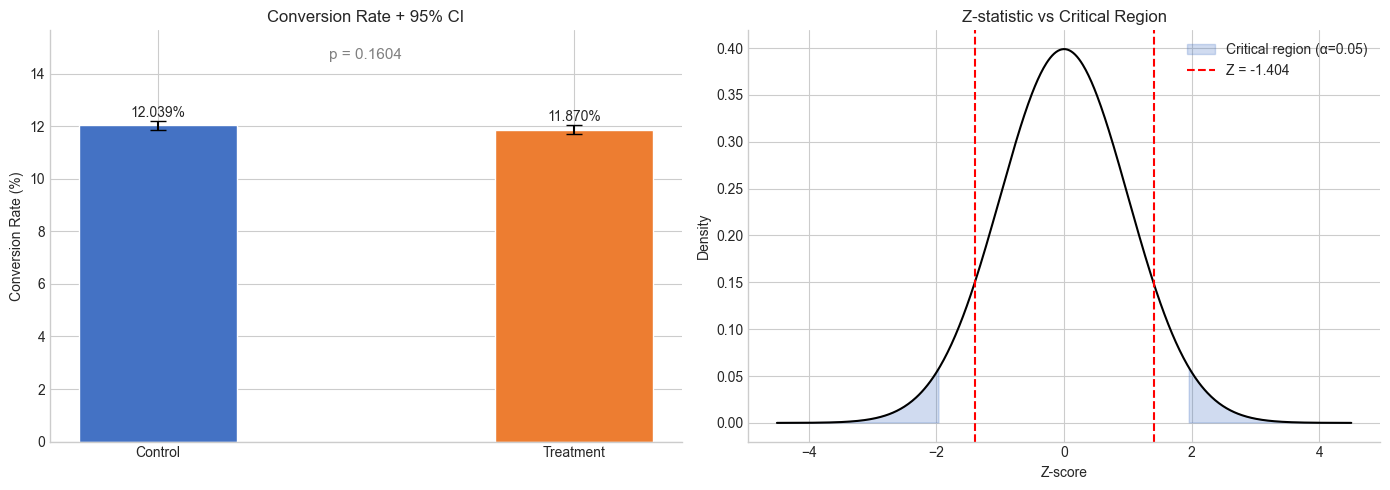

In [7]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Control', 'Treatment']
colors = ['#4472C4', '#ED7D31']
rates  = [rate_ctrl*100, rate_trt*100]
cis    = [ci_ctrl, ci_trt]

# Conversion rates with confidence intervals
ax = axes[0]
bars = ax.bar(labels, rates, color=colors, width=0.38, edgecolor='white')
for i, (rate, ci) in enumerate(zip(rates, cis)):
    ax.errorbar(i, rate,
                yerr=[[rate - ci[0]*100], [ci[1]*100 - rate]],
                fmt='none', color='black', capsize=6)
    ax.text(i, ci[1]*100 + 0.05, f"{rate:.3f}%", ha='center', va='bottom')
ax.set_ylim(0, max(rates)*1.3)
ax.set_title("Conversion Rate + 95% CI")
ax.set_ylabel("Conversion Rate (%)")
ax.annotate(f"p = {p_val:.4f}", xy=(0.5, 0.93), xycoords='axes fraction',
            ha='center', fontsize=11, color='green' if p_val < 0.05 else 'gray')

# Z-statistic vs critical region
ax2 = axes[1]
x = np.linspace(-4.5, 4.5, 600)
y = stats.norm.pdf(x)
ax2.plot(x, y, color='black')
ax2.fill_between(x, y, where=(np.abs(x) >= 1.96),
                 color='#4472C4', alpha=0.25, label='Critical region (α=0.05)')
ax2.axvline(z_stat, color='red', linestyle='--', label=f"Z = {z_stat:.3f}")
ax2.axvline(-z_stat, color='red', linestyle='--')
ax2.set_title("Z-statistic vs Critical Region")
ax2.set_xlabel("Z-score")
ax2.set_ylabel("Density")
ax2.legend()

# Show plot
plt.tight_layout()
plt.show()

In [8]:
import json

# Print experiment summary
print("SUMMARY")
print("="*50)
print(f"Control rate:    {rate_ctrl*100:.4f}%")
print(f"Treatment rate:  {rate_trt*100:.4f}%")
print(f"Absolute lift:   {(rate_trt - rate_ctrl)*100:+.4f} pp")
print(f"Relative lift:   {(rate_trt - rate_ctrl)/rate_ctrl*100:+.2f}%")
print(f"P-value:         {p_val:.6f}")
print(f"Cohen's h:       {h:.5f}  ({magnitude})")
print(f"Power:           {achieved_power*100:.1f}%")

# Save results to JSON file
results = {
    "rate_ctrl": rate_ctrl,
    "rate_trt": rate_trt,
    "n_ctrl": n_ctrl,
    "n_trt": n_trt,
    "conv_ctrl": int(conv_ctrl),
    "conv_trt": int(conv_trt),
    "z_stat": z_stat,
    "p_value": p_val,
    "cohens_h": h,
    "power": achieved_power,
    "ci_ctrl": list(ci_ctrl),
    "ci_trt": list(ci_trt)
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved: results.json")

SUMMARY
Control rate:    12.0393%
Treatment rate:  11.8698%
Absolute lift:   -0.1695 pp
Relative lift:   -1.41%
P-value:         0.160446
Cohen's h:       -0.00523  (Small)
Power:           28.9%

Saved: results.json
